# SWIGGY SALES ANALYSIS 

### import libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

#### import data 

In [2]:
df = pd.read_excel(r"D:\swiggy python analysis\swiggy_data.xlsx")


In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


#### Metadata

In [5]:
print("no of rows:",df.shape[0])   # shape tells u the no of total rows in the file 

no of rows: 197430


In [6]:
print("no of feilds:",df.shape[1])

no of feilds: 10


#### Data types

In [7]:
df.dtypes

State                         str
City                          str
Order Date         datetime64[us]
Restaurant Name               str
Location                      str
Category                      str
Dish Name                     str
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [8]:
df.describe()    # it gives a quick statistical summary of your data.

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996809,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


## KPI's

##### total sales

In [9]:
total_sales = df["Price (INR)"].sum()
print("Total sales INR:",round(total_sales,2))

Total sales INR: 53012505.77


#### Avg ratings

In [10]:
Avg_ratings = df["Rating"].mean()
print("Avg rating:",round(Avg_ratings,2))

Avg rating: 4.34


AVERAGE ORDER VALUE 

In [11]:
Avg_order_value = df["Price (INR)"].mean()
print("Average order value:",round(Avg_order_value,2))

Average order value: 268.51


Ratings count 

In [12]:
ratings_count = df["Rating Count"].sum()
print("Ratings count:", round(ratings_count, 2))


Ratings count: 5591574


Total orders 

In [13]:
print("Total orders:",len(df))

Total orders: 197430


## Charts Design

#### Monthly sales trend 

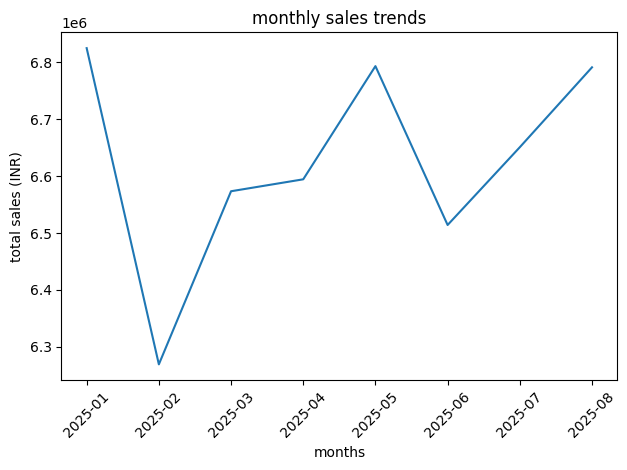

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)    # You can ONLY use .dt if data is already datetime . dt let us access date feature 
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.Figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation = 45)
plt.xlabel("months")
plt.ylabel("total sales (INR)")
plt.title("monthly sales trends")
plt.tight_layout()
plt.show()

Daily sales trends 

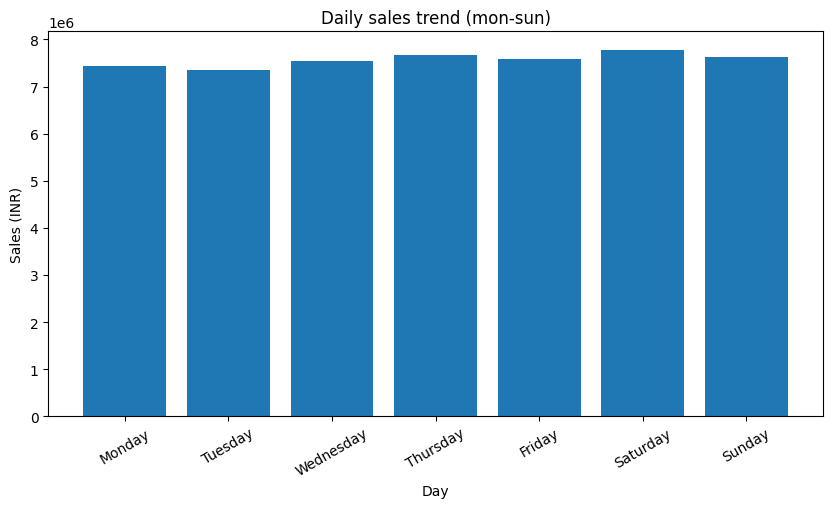

In [15]:
df["dayname"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = (df.groupby(["dayname"])["Price (INR)"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])) #Reorder, select, or add labels (index values) in your data

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily sales trend (mon-sun)")
plt.xlabel("Day")
plt.ylabel("Sales (INR)")
plt.xticks(rotation=30)
plt.show()





Total sales by food type (Veg vs Non-veg)

In [18]:
non_veg_keywords = ["chicken","egg","fish","mutton","prawn","biryani","kebab","kabab","non-veg","non veg"]

pattern = "|".join(non_veg_keywords)

df["Food category"] = np.where(
    df["Dish Name"].str.contains(pattern, case=False, na=False),
    "non-veg",
    "veg"
)

food_revenue = df.groupby("Food category")["Price (INR)"].sum().reset_index()

fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food category",
    hole=0.5,
    title="Revenue contribution: veg vs non-veg"
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.1, 0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()



Total sales by states

In [19]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
      .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)

fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()


Quarterly performance summary 

In [20]:
# 1️⃣ Convert Order Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order Date"])

# 2️⃣ Create Quarter column
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)

# 3️⃣ Create Quarterly Summary
quarterly_summary = (
    df.groupby("Quarter", as_index=False)
      .agg(
          Total_Sales=("Price (INR)", "sum"),
          Avg_Rating=("Rating", "mean"),
          Total_Orders=("Order_Date", "count")
      )
      .sort_values("Quarter")
)

# 4️⃣ Round values
quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

# 5️⃣ Show result
print(quarterly_summary)

  Quarter  Total_Sales  Avg_Rating  Total_Orders
0  2025Q1   19667822.0        4.34         73096
1  2025Q2   19902257.0        4.34         74163
2  2025Q3   13442427.0        4.34         50171


Top 5 cities by sales 

In [21]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
      .sum()
      .nlargest(5)
      .sort_values()
      .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()